In [1]:
import snappy
import khovanov
import itertools
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from knot_graphs import *
from geography import *

## Approach: do band moves entirely within kh package
### ~TODO - write `writhe` function for `khovanov.Link`~
### ~TODO - write `normal_euler_number` function for `khovanov.Cobordism`~
### Question: is it the case that $e(F) = - e(F')$ where $F'$ is the surface obtained by mirroring the knots on either end?
### TODO - compute $b_1(F)$ within `khovanov`
alternatively, we could try passing to snappy and praying that nothing gets messed up along the way...
### TODO - plot $e(F)$ vs $b_1(F)$

In [2]:
def writhe(link : khovanov.Link):
    link.orient()
    n_plus, n_minus = link.get_signs()
    n = len([c for c in link.crossings if len(c.adjacent) == 4])
    if n_plus + n_minus != n:
        print('something went wrong!')
        print(f'link: {link}')
        print(f'n = {len(link.crossings)}, n+ = {n_plus}, n- = {n_minus}')
    return n_plus - n_minus

In [3]:
def normal_euler_number(cob : khovanov.Cobordism):
    knot = cob.links[0]
    knot_prime = cob.links[-1]

    writhe_orig = writhe(knot)
    writhe_prime = writhe(knot_prime)
    return writhe_prime - writhe_orig

In [4]:
K = snappy.Link('3_1')
K_kh = khovanov.Link(K.PD_code())

['arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15']
{(0, 1, 0): -0.15, (0, 1, 1): 0.15, (1, 2, 0): -0.15, (1, 2, 1): 0.15, (2, 0, 0): -0.15, (2, 0, 1): 0.15}


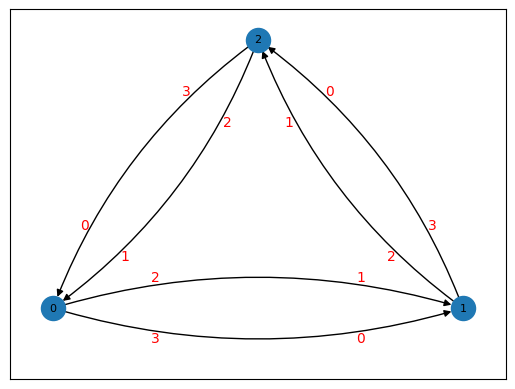

In [5]:
draw_adjacency_graph(K)

In [6]:
cob = khovanov.Cobordism(K_kh)
cob.band_move(0, (0,0), (0,1))
print(normal_euler_number(cob))

6


In [7]:
def try_bands(knot : khovanov.Link):
    crossings = knot.crossings
    strands = [0,1,2,3]
    good_bands = 0
    failed_bands = 0
    twists = []
    c0s = []
    s0s = []
    c1s = []
    s1s = []
    es = []
    for twist in [-1,0,1]:
        for (c0, s0) in itertools.product(crossings, strands):
            for (c1, s1) in itertools.product(crossings, strands):
                if c0 == c1 and s0 == s1: continue
                try:
                    cob = khovanov.Cobordism(knot)
                    cob.band_move(twist, (c0,s0), (c1,s1))
                    e = normal_euler_number(cob)
                    
                    twists.append(twist)
                    c0s.append(c0)
                    s0s.append(s0)
                    c1s.append(c1)
                    s1s.append(s1)
                    es.append(e)

                    
                    
                    good_bands += 1
                except:
                    failed_bands += 1
                    continue

    print(f'bands found: {good_bands}')
    print(f'number of failed band moves: {failed_bands}')
    
    return pd.DataFrame(zip(twists, c0s, s0s, c1s, s1s, es),
                        columns=['twist', 'c0', 's0', 'c1', 's1', 'e'])

In [8]:
def plot_bands(Ksnappy, bands_df, erange=(-40,40), brange=(0,30)):
    # use existing plotting code
    # plot df points
    fig, ax = plot_bounds(Ksnappy, erange=erange, brange=brange)
    ax.vlines(bands_df['e'], -100, 100, colors='red')
    return fig, ax

#### Trefoil $3_1$

In [9]:
bands_K = try_bands(K_kh)
with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(bands_K)

bands found: 228
number of failed band moves: 168


,twist,c0,s0,c1,s1,e
0,-1,0,0,0,2,1
1,-1,0,0,0,3,3
2,-1,0,0,1,2,1
3,-1,0,0,1,3,3
4,-1,0,0,2,2,5
5,-1,0,0,2,3,1
6,-1,0,1,0,2,3
7,-1,0,1,0,3,1
8,-1,0,1,1,2,3
9,-1,0,1,1,3,1


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': '$b_1$ bounds'}, xlabel='$e$', ylabel='$b_1$'>)

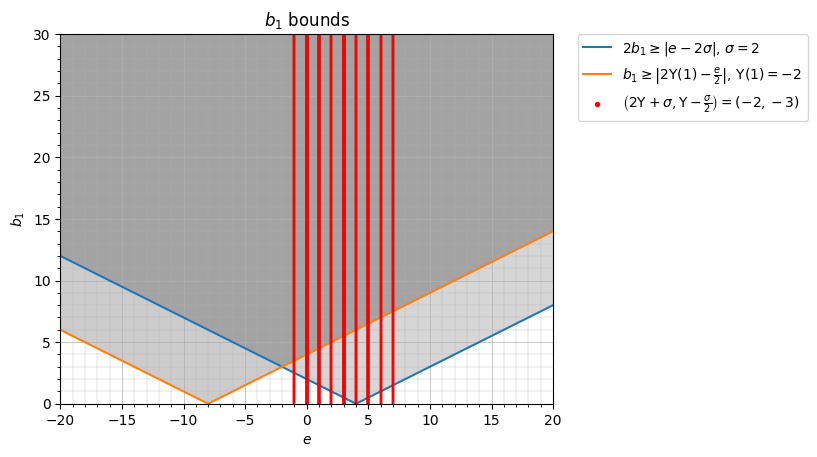

In [10]:
plot_bands(K, bands_K, erange=(-20,20))

#### Mirrored trefoil $-3_1$

In [11]:
bands_mirror_K = try_bands(K_kh.mirror())
bands_mirror_K
with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(bands_mirror_K)

bands found: 228
number of failed band moves: 168


,twist,c0,s0,c1,s1,e
0,-1,0,0,0,1,-5
1,-1,0,0,0,2,-3
2,-1,0,0,1,1,1
3,-1,0,0,1,2,-7
4,-1,0,0,2,1,-5
5,-1,0,0,2,2,-3
6,-1,0,1,0,0,-5
7,-1,0,1,0,3,-3
8,-1,0,1,1,0,-5
9,-1,0,1,1,3,-3


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': '$b_1$ bounds'}, xlabel='$e$', ylabel='$b_1$'>)

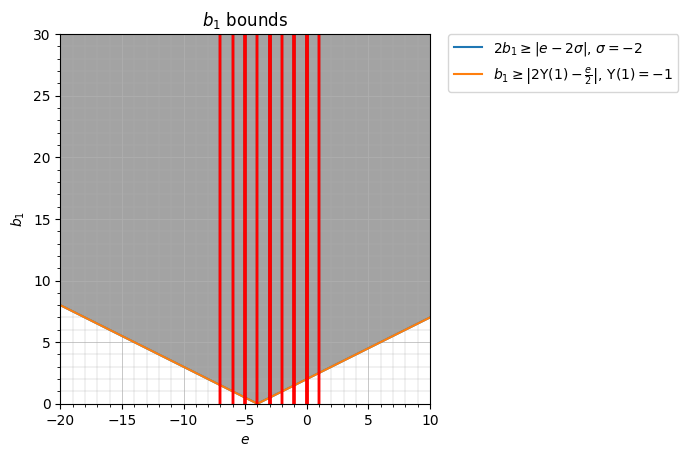

In [12]:
plot_bands(K.mirror(), bands_mirror_K, erange=(-20,10))

#### Torus Knots $T(4,q)$

In [27]:
T45 = snappy.Link('T(4,5)')
T45_kh = khovanov.Link(T45.PD_code())
bands_T45 = try_bands(T45_kh)
with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(bands_mirror_K)

bands found: 5460
number of failed band moves: 5160


,twist,c0,s0,c1,s1,e
0,-1,0,0,0,1,-5
1,-1,0,0,0,2,-3
2,-1,0,0,1,1,1
3,-1,0,0,1,2,-7
4,-1,0,0,2,1,-5
5,-1,0,0,2,2,-3
6,-1,0,1,0,0,-5
7,-1,0,1,0,3,-3
8,-1,0,1,1,0,-5
9,-1,0,1,1,3,-3


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': '$b_1$ bounds'}, xlabel='$e$', ylabel='$b_1$'>)

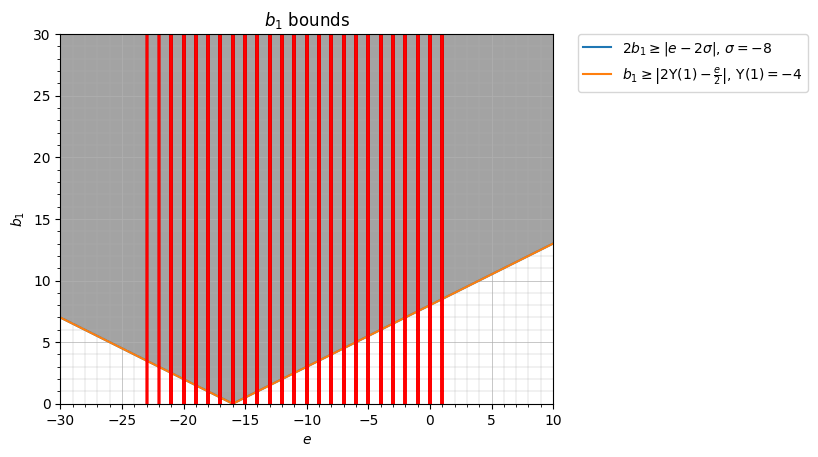

In [28]:
plot_bands(T45, bands_T45, erange=(-30,10))

In [29]:
T47 = snappy.Link('T(4,7)')
T47_kh = khovanov.Link(T45.PD_code())
bands_T47 = try_bands(T47_kh)
with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(bands_mirror_K)

bands found: 5460
number of failed band moves: 5160


,twist,c0,s0,c1,s1,e
0,-1,0,0,0,1,-5
1,-1,0,0,0,2,-3
2,-1,0,0,1,1,1
3,-1,0,0,1,2,-7
4,-1,0,0,2,1,-5
5,-1,0,0,2,2,-3
6,-1,0,1,0,0,-5
7,-1,0,1,0,3,-3
8,-1,0,1,1,0,-5
9,-1,0,1,1,3,-3


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': '$b_1$ bounds'}, xlabel='$e$', ylabel='$b_1$'>)

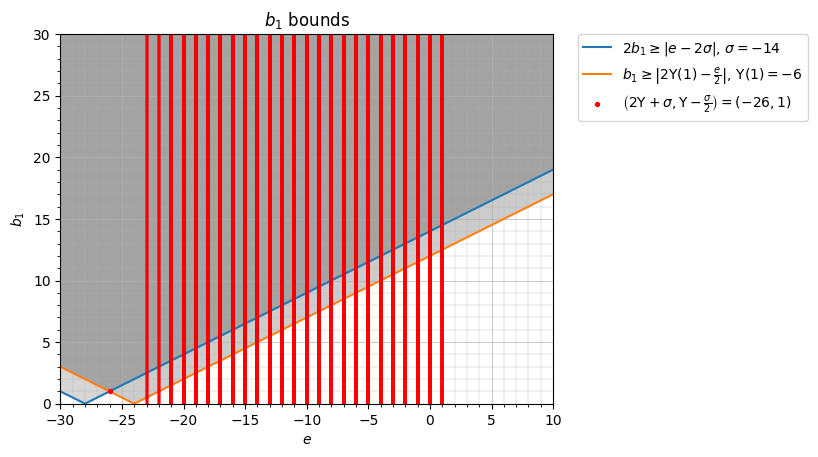

In [30]:
plot_bands(T47, bands_T47, erange=(-30,10))

## ~Approach - write band move function from scratch~

### Bands are described by paths in the dual graph with additional data about over/under crossings at strand intersections

### TODO - draw dual graph on top of adjacency crossing graph

#### the goal here is to draw the dual graph over top of the knot diagram itself

In [13]:
K = snappy.Link('4_1')
dg = K.dual_graph()

In [14]:
vars(dg)

{'vertices': {<F0>, <F1>, <F2>, <F3>, <F4>, <F5>},
 'edges': {<F0> --- <F1>,
  <F0> --- <F3>,
  <F0> --- <F4>,
  <F1> --- <F2>,
  <F2> --- <F3>,
  <F2> --- <F4>,
  <F3> --- <F5>,
  <F4> --- <F5>},
 'incidence_dict': {<F0>: [<F0> --- <F1>, <F0> --- <F3>, <F0> --- <F4>],
  <F1>: [<F0> --- <F1>, <F1> --- <F2>],
  <F3>: [<F0> --- <F3>, <F2> --- <F3>, <F3> --- <F5>],
  <F4>: [<F0> --- <F4>, <F2> --- <F4>, <F4> --- <F5>],
  <F2>: [<F1> --- <F2>, <F2> --- <F3>, <F2> --- <F4>],
  <F5>: [<F3> --- <F5>, <F4> --- <F5>]},
 'Edge': spherogram.graphs.Edge,
 'edge_to_face': {<CS 3, 3>: <F0>,
  <CS 0, 3>: <F0>,
  <CS 2, 1>: <F0>,
  <CS 3, 2>: <F1>,
  <CS 2, 2>: <F1>,
  <CS 3, 1>: <F2>,
  <CS 2, 3>: <F2>,
  <CS 1, 3>: <F2>,
  <CS 3, 0>: <F3>,
  <CS 1, 0>: <F3>,
  <CS 0, 2>: <F3>,
  <CS 2, 0>: <F4>,
  <CS 0, 0>: <F4>,
  <CS 1, 2>: <F4>,
  <CS 1, 1>: <F5>,
  <CS 0, 1>: <F5>}}

In [15]:
dg_nx = dg.to_networkx()

In [16]:
dg_nx.nodes.data()

NodeDataView({<F2>: {}, <F3>: {}, <F0>: {}, <F5>: {}, <F1>: {}, <F4>: {}})

In [17]:
dg_nx.edges

MultiEdgeView([(<F2>, <F3>, 0), (<F2>, <F1>, 0), (<F2>, <F4>, 0), (<F3>, <F0>, 0), (<F3>, <F5>, 0), (<F0>, <F4>, 0), (<F0>, <F1>, 0), (<F5>, <F4>, 0)])

In [18]:
def draw_dual_graph(knot):
    dg = knot.dual_graph().to_networkx()
    layout = nx.spring_layout(dg)
    nx.draw_networkx(dg, pos=layout)
    #nx.draw_networkx_labels(dg, pos=layout, font_size=10)

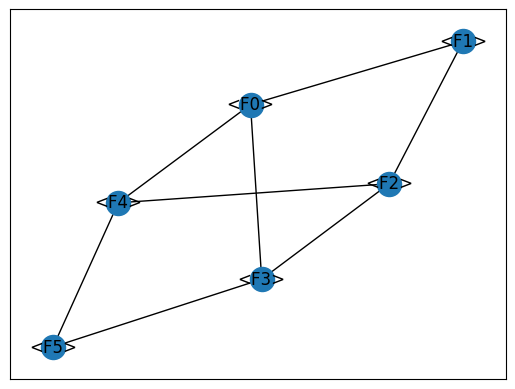

In [19]:
draw_dual_graph(K)

['arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0']
{(0, 1, 0): -0.15, (0, 3, 0): 0, (1, 0, 0): -0.15, (1, 2, 0): 0, (2, 3, 0): -0.15, (2, 0, 0): 0, (3, 2, 0): -0.15, (3, 1, 0): 0}


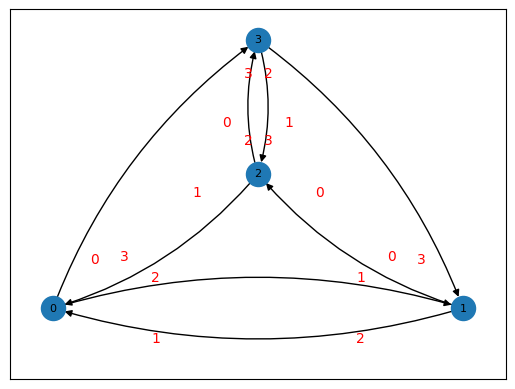

In [20]:
draw_adjacency_graph(K)